In [1]:
"""
Aplica una transformacion lineal a una imagen en un espacio de color especifico
Autor: Natalia Rendón
Curso: Procesamiento de Imágenes
"""

'\nAplica una transformacion lineal a una imagen en un espacio de color especifico\nAutor: Natalia Rendón\nCurso: Procesamiento de Imágenes\n'

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os

In [11]:
def apply_linear_transformation(image, k, color_space):
    """
  
    Parametros:
    -----------
    image: numpy.ndarray
        Imagen a transformar con valores en rango [0,255]
    k: float
        Constante por la que se multiplicaran los valores de los pixeles
        k > 1: aclara la imagen
        k < 1: oscurece la imagen
        k = 1: imagen sin cambios
    color_space: str
        Espacio de color de la imagen ('RGB', 'CMY', 'HSI')

    Retorna:
    --------
    numpy.ndarray
        Imagen transformada con valores en el rango [0,255]
    """
    # Validar que la imagen no sea None
    if image is None:
        raise ValueError("La imagen no puede ser None")
    
    # Validar que k sea positivo
    if k <= 0:
        raise ValueError(f"k debe ser positivo, se recibio: {k}")
    
    if color_space == 'RGB':
        transformed_image = cv2.convertScaleAbs(image, alpha=k, beta=0)
        
    elif color_space == 'CMY':
        # Para CMY, beta=(1-k) mantiene la relacion inversa con RGB
        transformed_image = cv2.convertScaleAbs(image, alpha=k, beta=(1-k)*255)
        
    elif color_space == 'HSI':
        # En HSI solo se modifica el canal de Intensidad (I)
        H, S, I = image[:,:,0], image[:,:,1], image[:,:,2]
        I_transformed = k * I
        transformed_image = np.stack((H, S, I_transformed), axis=-1)
        
    else:
        raise ValueError(f"Espacio de color no soportado: {color_space}. Usar 'RGB', 'CMY' o 'HSI'")
    
    # Asegurar que los valores esten en rango [0,255]
    transformed_image = np.clip(transformed_image, 0, 255)
    
    return transformed_image.astype(np.uint8)

def RGB2CMY(img):
    # Validar que la imagen no esté vacía
    if img is None:
        raise ValueError("No se pudo cargar la imagen")
    
    # Validar que tenga 3 canales (RGB)
    if len(img.shape) != 3 or img.shape[2] != 3:
        raise ValueError("La imagen debe tener 3 canales (RGB)")
    
    # Normalizar valores a rango [0,1]
    imagen_rgb_normalized = img.astype(np.float32) / 255.0
    
    # Calcular componentes CMY
    C = 1 - imagen_rgb_normalized[:, :, 0]
    M = 1 - imagen_rgb_normalized[:, :, 1]
    Y = 1 - imagen_rgb_normalized[:, :, 2]
    
    # Combinar canales
    imagen_cmy = cv2.merge((C, M, Y))
    
    return imagen_cmy

def RGB2HSI(rgb_image):
    # Validar entrada
    if rgb_image is None:
        raise ValueError("La imagen no puede ser None")
    
    if len(rgb_image.shape) != 3 or rgb_image.shape[2] != 3:
        raise ValueError("La imagen debe tener 3 canales (RGB)")
    
    # Normalizar valores a rango [0,1]
    rgb_normalized = rgb_image.astype(np.float32) / 255.0
    
    # Extraer canales R, G, B
    R = rgb_normalized[:, :, 0]
    G = rgb_normalized[:, :, 1]
    B = rgb_normalized[:, :, 2]
    
    # Calcular Intensidad (I)
    I = (R + G + B) / 3.0
    
    # Calcular Saturación (S)
    # Evitar división por cero agregando epsilon
    epsilon = 1e-10
    min_rgb = np.minimum(np.minimum(R, G), B)
    S = 1 - (3 * min_rgb) / (R + G + B + epsilon)
    
    # Calcular Hue (H)
    numerator = 0.5 * ((R - G) + (R - B))
    denominator = np.sqrt((R - G)**2 + (R - B)*(G - B))
    
    # Calcular theta (ángulo en radianes)
    # Evitar divisiones por cero
    cos_theta = numerator / (denominator + epsilon)
    # Limitar valores a [-1, 1] para evitar errores numéricos
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    theta = np.arccos(cos_theta)
    
    # Calcular H según el valor de B
    H = theta.copy()
    H[B > G] = 2 * np.pi - H[B > G]
    
    # Normalizar H a [0, 1] (dividiendo entre 2π)
    H = H / (2 * np.pi)
    
    # Combinar canales
    hsi_image = np.dstack((H, S, I))
    
    return hsi_image


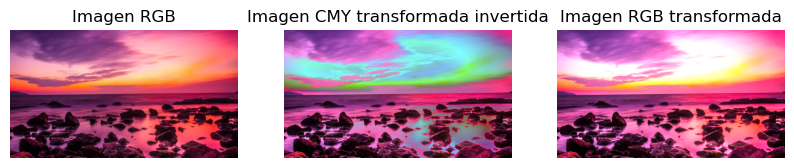

In [12]:
ruta_imagen = "sunset.jpg"  # O "sunset.jpg" si está en la raíz
img = cv2.imread(ruta_imagen)
imagen_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
imagen_cmy = RGB2CMY(imagen_rgb)*255
imagen_hsi = RGB2HSI(imagen_rgb)

imagen_cmy_k=apply_linear_transformation(imagen_cmy.astype(np.uint8), 1.5, "CMY")
#imagen_cmy_2= imagen_cmy*255
inverted= cv2.bitwise_not(imagen_cmy_k.astype(np.uint8))

imagen_rgb_k=apply_linear_transformation(imagen_rgb, 1.5, "RGB")

plt.figure(figsize=(10, 5))
plt.subplot(1,3,1)
plt.imshow(imagen_rgb)
plt.title('Imagen RGB')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(inverted)
plt.title('Imagen CMY transformada invertida')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(imagen_rgb_k)
plt.title('Imagen RGB transformada')
plt.axis('off') 
plt.show()